In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

In [3]:
data.shape

(299, 13)

In [4]:
data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [6]:
print(data['DEATH_EVENT'].value_counts())

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [7]:
data.isna().sum()

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64

In [8]:
data.duplicated().sum()

np.int64(0)

In [9]:
X = data.drop(columns=['DEATH_EVENT'])
y = data['DEATH_EVENT']

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [ ]:
# Feature Scaling (Requirement: apply if required)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
from imblearn.over_sampling import SMOTE

In [15]:
# Section 9: Balance Dataset (Requirement: since imbalanced)
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE:", pd.Series(y_train_balanced).value_counts().to_dict())


After SMOTE: {0: 162, 1: 162}


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)

In [17]:
# Train Different Models and Compare
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100)
}

results = []
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
results_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.800000,0.733333,0.578947,0.647059
1,Decision Tree,0.783333,0.625000,0.789474,0.697674
2,Random Forest,0.816667,0.722222,0.684211,0.702703



===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        41
           1       0.73      0.58      0.65        19

    accuracy                           0.80        60
   macro avg       0.78      0.74      0.75        60
weighted avg       0.79      0.80      0.79        60



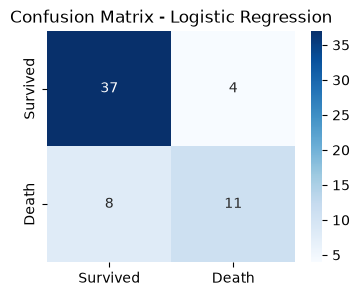


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        41
           1       0.62      0.79      0.70        19

    accuracy                           0.78        60
   macro avg       0.76      0.78      0.76        60
weighted avg       0.81      0.78      0.79        60



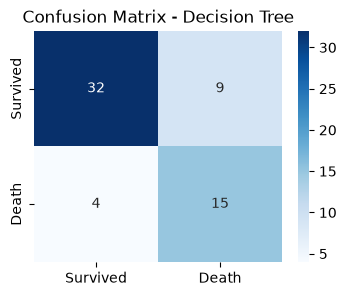


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60



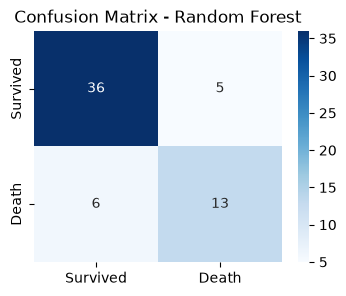

In [18]:
# Classification Report + Confusion Matrix (Required for each model)
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    print(f"\n===== {name} =====")
    print(classification_report(y_test, preds))

    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Survived', 'Death'], yticklabels=['Survived', 'Death'])
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [19]:
# Select Best Model
best_model_name = results_df.sort_values("F1-Score", ascending=False).iloc[0]["Model"]
print("Best model:", best_model_name)

Best model: Random Forest


In [22]:
# Hyperparameter Tuning (Requirement: improve performance)
param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train_balanced, y_train_balanced)
print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': None, 'n_estimators': 100}


Accuracy:  0.8166666666666667
Precision: 0.7222222222222222
Recall:    0.6842105263157895
F1-Score:  0.7027027027027027

               precision    recall  f1-score   support

           0       0.86      0.88      0.87        41
           1       0.72      0.68      0.70        19

    accuracy                           0.82        60
   macro avg       0.79      0.78      0.79        60
weighted avg       0.81      0.82      0.82        60



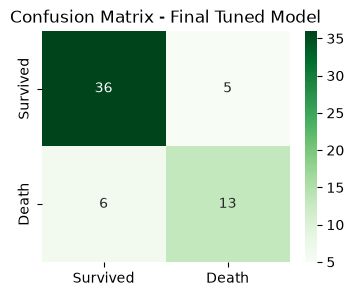

In [23]:
# Final Tuned Model Evaluation
best_model = grid_search.best_estimator_
final_preds = best_model.predict(X_test_scaled)

print("Accuracy: ", accuracy_score(y_test, final_preds))
print("Precision:", precision_score(y_test, final_preds))
print("Recall:   ", recall_score(y_test, final_preds))
print("F1-Score: ", f1_score(y_test, final_preds))
print("\n", classification_report(y_test, final_preds))

cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Survived', 'Death'], yticklabels=['Survived', 'Death'])
plt.title("Confusion Matrix - Final Tuned Model")
plt.show()